<h1><strong>Hierarchical Clustering</strong></h1>

Hierarchical Clustering is an unsupervised machine learning algorithm that groups similar datapoints into clusters based on distance.

Types of Hierarchical clustering:

- Agglomerative(Bottom - up) (most used)
- Divisive(Top - Bottom)

1. Agglomerative

- Start with each point as its own cluster
- Merge closest clusters step-by-step

2. Divisive

- Start with all data in one cluster
- Split recursively

Distance Metrics:

- Euclidean Distance(Most common)
- Manhattan Distance
- cosine Distance

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram,linkage
from sklearn.cluster import AgglomerativeClustering

In [55]:
X,_ = make_blobs(n_samples=300,centers=4,random_state=42)

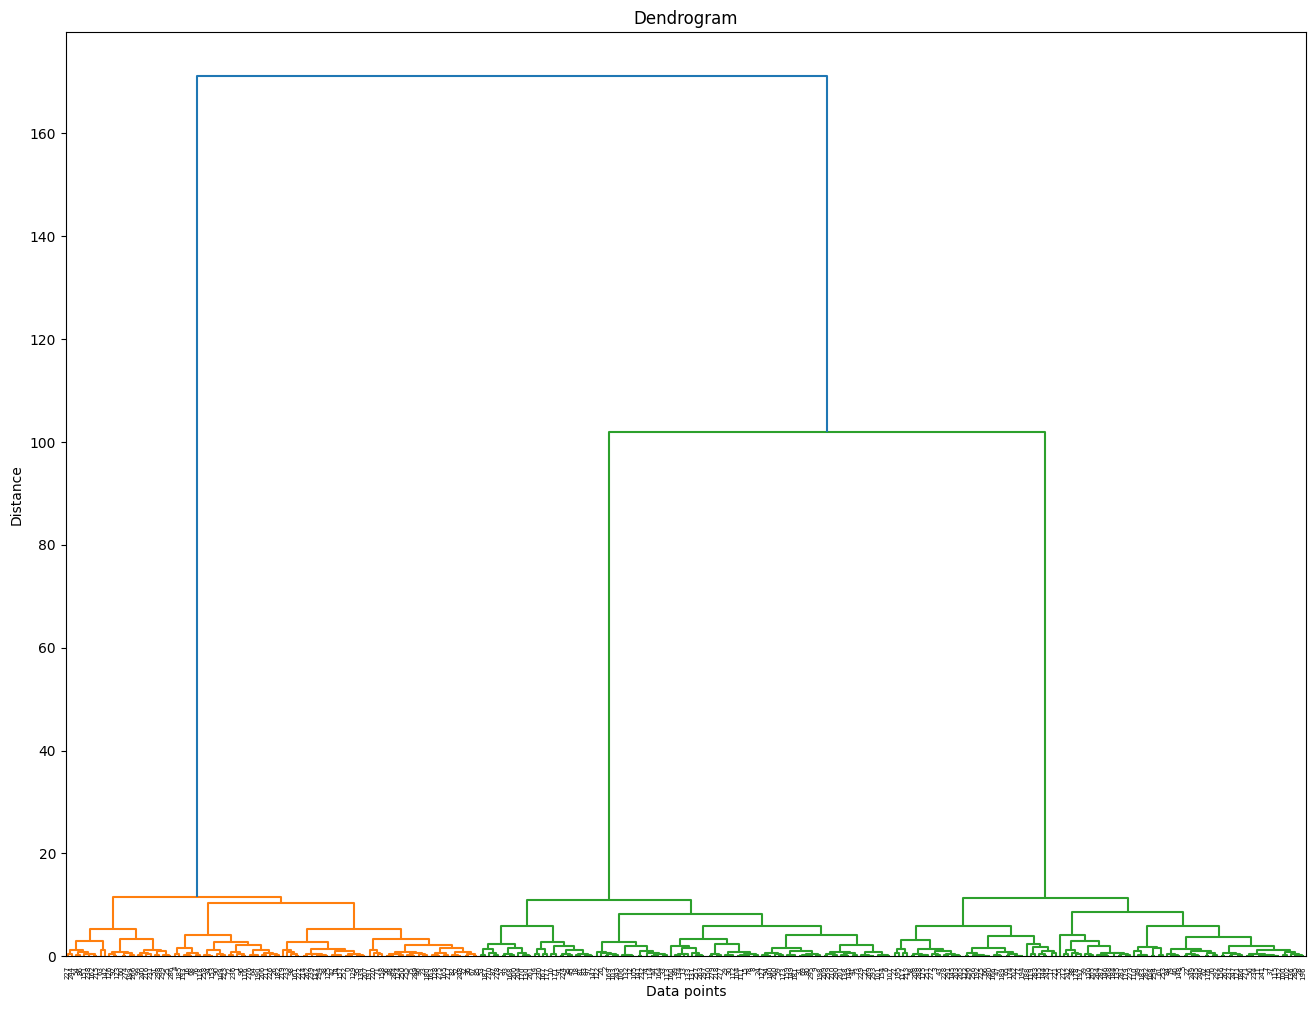

In [38]:
linked = linkage(X,method='ward')

plt.figure(figsize=(16,12))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data points")
plt.ylabel("Distance")
plt.show()

In [40]:
model = AgglomerativeClustering(n_clusters=3,linkage='ward')
labels = model.fit_predict(X)

Text(0.5, 1.0, 'Hierarchical clustering result')

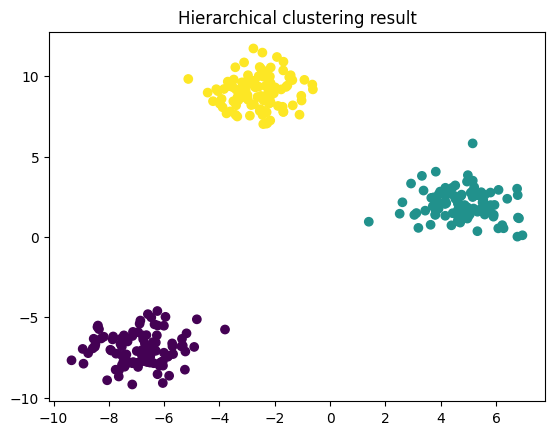

In [41]:
plt.scatter(X[:,0],X[:,1],c=labels)
plt.title("Hierarchical clustering result")

In [42]:
lbls = []
for method in ['ward','complete','average','single']:
    model = AgglomerativeClustering(n_clusters=4,linkage=method)
    lbls.append(model.fit_predict(X))

ward

Text(0.5, 1.0, 'Hierarchical clustering result')

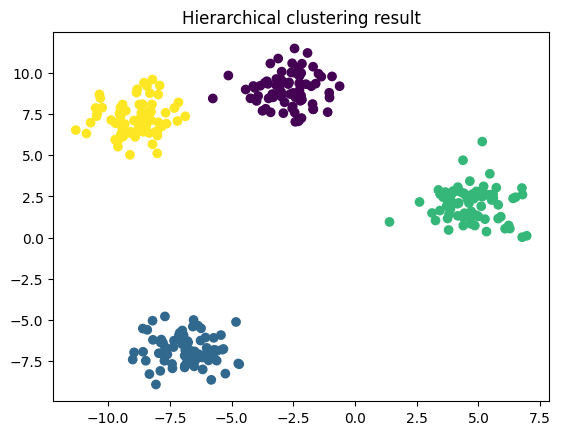

In [24]:
plt.scatter(X[:,0],X[:,1],c=lbls[0])
plt.title("Hierarchical clustering result")

complete

Text(0.5, 1.0, 'Hierarchical clustering result')

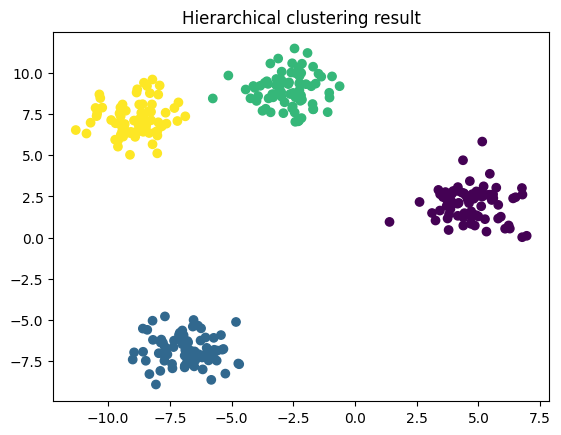

In [25]:
plt.scatter(X[:,0],X[:,1],c=lbls[1])
plt.title("Hierarchical clustering result")

average

Text(0.5, 1.0, 'Hierarchical clustering result')

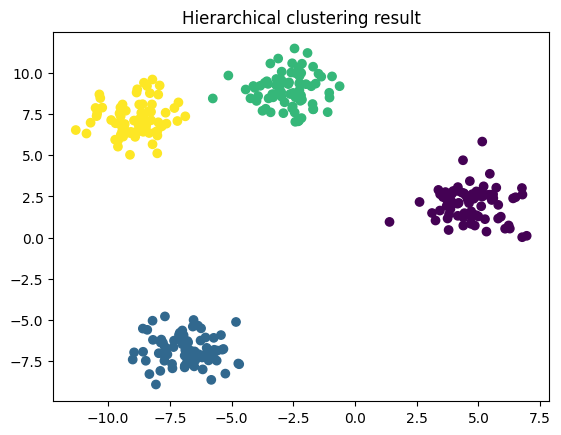

In [26]:
plt.scatter(X[:,0],X[:,1],c=lbls[2])
plt.title("Hierarchical clustering result")

single

Text(0.5, 1.0, 'Hierarchical clustering result')

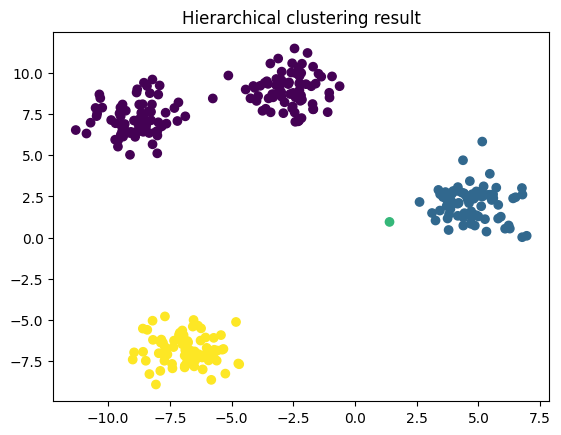

In [27]:
plt.scatter(X[:,0],X[:,1],c=lbls[3])
plt.title("Hierarchical clustering result")

Silhouette Score

In [43]:
from sklearn.metrics import silhouette_score

In [44]:
score = silhouette_score(X,labels)
print(score)

0.8480303059596955


In [45]:
stScore = {}
for n in range(2,10):
    model = AgglomerativeClustering(n_clusters=n,linkage='ward')
    labels = model.fit_predict(X)
    stScore[n]=silhouette_score(X,labels)

In [46]:
stScore

{2: 0.7049437310743717,
 3: 0.8480303059596955,
 4: 0.6648901075977273,
 5: 0.4892559100691162,
 6: 0.32713350065991315,
 7: 0.3477105845136554,
 8: 0.3542384794979673,
 9: 0.3433779792440253}

<h1>Divisive</h1>

In [47]:
from sklearn.cluster import KMeans

In [51]:
def divisive_clustering(X,depth=2):
    clusters = [X]

    for _ in range(depth):
        new_clusters =[]

        for cluster in clusters:
            if len(cluster)<=1:
                new_clusters.append(cluster)
                continue

            kmeans = KMeans(n_clusters=2,random_state=42)
            labels = kmeans.fit_predict(cluster)

            cluster_1 = cluster[labels==0]
            cluster_2 = cluster[labels==1]

            new_clusters.extend([cluster_1,cluster_2])

        clusters = new_clusters
    return clusters

In [56]:
clusters = divisive_clustering(X,depth=2)

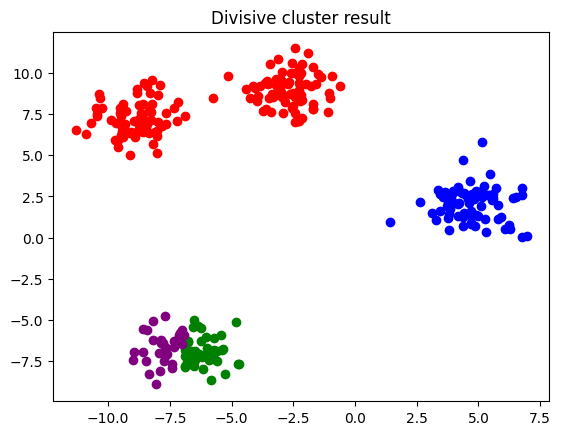

In [57]:
colors = ['red','blue','green','purple','orange']
for i ,cluster in enumerate(clusters):
    plt.scatter(cluster[:,0],cluster[:,1],color=colors[i%len(colors)])
plt.title("Divisive cluster result")
plt.show()